# SiteSafe Vision: AI-Powered Construction PPE Screening System
### End-to-End Transfer Learning, MLOps Lineage, Audits & Demonstration

> ⚠️ **SAFETY & REGULATORY DISCLAIMER**: This notebook and the associated models provide an image-based screening aid. This system does NOT perform autonomous safety inspections, guaranteed object detection, or certified workplace safety assessments.

---

## 1. Environment & Hardware Verification (`scripts/environment_report.py`)
Captures OS, CPU, GPU, CUDA, PyTorch, Torchvision, Git commit, and DVC versions.

In [1]:
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# Ensure project root is in sys.path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.seed import set_seed
set_seed(42)

from scripts.environment_report import generate_environment_report
env_report = generate_environment_report(PROJECT_ROOT)

print("=" * 60)
print("  ENVIRONMENT SIGNATURE REPORT")
print("=" * 60)
print(f"OS: {env_report['system']['os']} {env_report['system']['os_release']}")
print(f"Python Version: {env_report['system']['python_version'].split()[0]}")
print(f"PyTorch Version: {env_report['dependencies']['torch']}")
print(f"Torchvision Version: {env_report['dependencies']['torchvision']}")
print(f"CUDA Available: {env_report['hardware']['cuda_available']}")
print(f"Git Commit: {env_report['version_control']['git_commit']}")
print(f"DVC Version: {env_report['version_control']['dvc_version']}")

[SUCCESS] Environment report saved to C:\Users\hp\OneDrive\Desktop\Code\Site Safe Vision\reports\environment.json
  ENVIRONMENT SIGNATURE REPORT
OS: Windows 10
Python Version: 3.11.9
PyTorch Version: 2.13.0+cpu
Torchvision Version: 0.28.0+cpu
CUDA Available: False
Git Commit: 1b14c0cd456bed4e0816b044a7d00df48fa95532
DVC Version: DVC version: 3.67.1 (pip)


## 2. Dataset Provenance & Ingestion Metadata
Primary source: Roboflow Universe Construction PPE Detection Dataset (CC BY 4.0).

In [2]:
meta_path = PROJECT_ROOT / "data" / "raw" / "dataset_metadata.json"
with open(meta_path, "r", encoding="utf-8") as f:
    dataset_metadata = json.load(f)

print(f"Dataset: {dataset_metadata['dataset_name']}")
print(f"Source URL: {dataset_metadata['source_url']}")
print(f"License: {dataset_metadata['license']}")
print(f"Raw Scenes: {dataset_metadata['image_count']}")
print(f"Total Bounding Box Annotations: {dataset_metadata['annotation_count']}")
print(f"Raw Class Distribution: {dataset_metadata['class_distribution']}")

Dataset: Construction PPE Detection Dataset
Source URL: https://universe.roboflow.com/new-project-ds9wg/construction-ppe-detection-vqbc0
License: CC BY 4.0
Raw Scenes: 120
Total Bounding Box Annotations: 612
Raw Class Distribution: {'human': 185, 'helmet': 100, 'vest': 100, 'boots': 122, 'gloves': 105}


## 3. Auditable Label Derivation & Quality Audit
Transforms object detection bounding boxes into worker-centered crops with spatial band rules.

In [3]:
label_audit_df = pd.read_csv(PROJECT_ROOT / "data" / "interim" / "label_audit.csv")
print(f"Total Processed Worker Candidates: {len(label_audit_df)}")
print("\nDerived Compliance Distribution:")
print(label_audit_df["derived_label"].value_counts())

display(label_audit_df.head(5))

Total Processed Worker Candidates: 185

Derived Compliance Distribution:
derived_label
PARTIAL_PPE    70
FULL_PPE       65
NO_PPE         50
Name: count, dtype: int64


,source_image_id,crop_id,worker_bbox,helmet_present,vest_present,boots_present,gloves_present,derived_label,label_confidence,rejection_reason,transformation_version
0,scene_0000,scene_0000_w00,"[159,232,113,350]",False,False,True,False,NO_PPE,1.0,NONE,1.0.0
1,scene_0000,scene_0000_w01,"[480,383,153,240]",False,True,False,True,PARTIAL_PPE,1.0,NONE,1.0.0
2,scene_0001,scene_0001_w00,"[99,232,103,228]",True,True,False,True,FULL_PPE,1.0,NONE,1.0.0
3,scene_0001,scene_0001_w01,"[290,260,97,254]",True,True,True,False,FULL_PPE,1.0,NONE,1.0.0
4,scene_0001,scene_0001_w02,"[518,325,93,273]",False,False,True,True,NO_PPE,1.0,NONE,1.0.0


## 4. Leakage Prevention & Grouped Split Manifest
Worker crops from the same source scene strictly remain in the same split.

In [4]:
split_manifest_df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "split_manifest.csv")
print("Class Distribution across Grouped Splits:")
display(pd.crosstab(split_manifest_df["split"], split_manifest_df["class"], margins=True))

Class Distribution across Grouped Splits:


class,FULL_PPE,NO_PPE,PARTIAL_PPE,All
split,,,,
test,8,7,12,27
train,50,35,49,134
val,7,8,9,24
All,65,50,70,185


## 5. Model Training & Comparison (ResNet50 vs. MobileNetV3-Large)

In [5]:
with open(PROJECT_ROOT / "artifacts" / "models" / "metadata_resnet50.json", "r") as f:
    resnet_meta = json.load(f)
with open(PROJECT_ROOT / "artifacts" / "models" / "metadata_mobilenet_v3_large.json", "r") as f:
    mobilenet_meta = json.load(f)

comp_df = pd.DataFrame([
    {
        "Model": "MobileNetV3-Large (Champion)",
        "Val Macro F1": mobilenet_meta["validation_metrics"]["macro_f1"],
        "Val Accuracy": mobilenet_meta["validation_metrics"]["accuracy"],
        "Unsafe Recall Min": mobilenet_meta["validation_metrics"]["safety_audit"]["unsafe_recall_min"],
        "Val Loss": mobilenet_meta["validation_metrics"]["loss"],
    },
    {
        "Model": "ResNet50 (Baseline)",
        "Val Macro F1": resnet_meta["validation_metrics"]["macro_f1"],
        "Val Accuracy": resnet_meta["validation_metrics"]["accuracy"],
        "Unsafe Recall Min": resnet_meta["validation_metrics"]["safety_audit"]["unsafe_recall_min"],
        "Val Loss": resnet_meta["validation_metrics"]["loss"],
    }
])
display(comp_df)

,Model,Val Macro F1,Val Accuracy,Unsafe Recall Min,Val Loss
0,MobileNetV3-Large (Champion),0.9608,0.9583,0.8889,0.6069
1,ResNet50 (Baseline),0.7556,0.7500,0.6667,0.9619


## 6. Formal Model Selection & Test Set Benchmark

In [6]:
with open(PROJECT_ROOT / "reports" / "evaluation_results.json", "r") as f:
    test_eval = json.load(f)

print(f"Champion Model: {test_eval['model_name']}")
print(f"Test Accuracy: {test_eval['metrics']['accuracy'] * 100:.2f}%")
print(f"Test Macro F1: {test_eval['metrics']['macro_f1']:.4f}")
print(f"Test Macro Recall: {test_eval['metrics']['macro_recall']:.4f}")
print(f"Critical NO_PPE False Negatives: {test_eval['metrics']['safety_audit']['no_ppe_critical_fn_count']}")
print(f"Inference Latency: {test_eval['metrics']['latency_per_sample_ms']:.2f} ms/image")

print("\nConfusion Matrix (Rows=True, Cols=Pred: [FULL_PPE, PARTIAL_PPE, NO_PPE]):")
for r in test_eval["metrics"]["confusion_matrix"]:
    print(" ", r)

Champion Model: mobilenet_v3_large
Test Accuracy: 88.89%
Test Macro F1: 0.8931
Test Macro Recall: 0.9167
Critical NO_PPE False Negatives: 0
Inference Latency: 26.98 ms/image

Confusion Matrix (Rows=True, Cols=Pred: [FULL_PPE, PARTIAL_PPE, NO_PPE]):
  [8, 0, 0]
  [2, 9, 1]
  [0, 0, 7]


## 7. Performance Benchmarking (`scripts/benchmark_performance.py`)

2026-09-14 02:10:12 [INFO] [benchmark] Executing Performance Benchmark on ResNet50 and MobileNetV3-Large...
2026-09-14 02:11:20 [INFO] [benchmark] Performance report saved to C:\Users\hp\OneDrive\Desktop\Code\Site Safe Vision\reports\performance.json


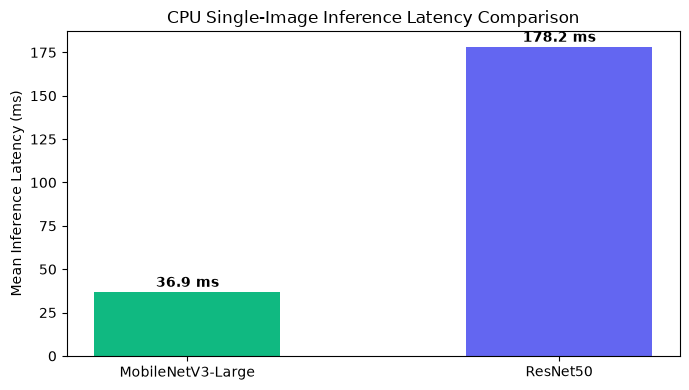

In [7]:
from scripts.benchmark_performance import run_full_benchmark
bench_results = run_full_benchmark()

mob_lat = bench_results["architectures"]["mobilenet_v3_large"]["single_image_latency_ms"]
res_lat = bench_results["architectures"]["resnet50"]["single_image_latency_ms"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["MobileNetV3-Large", "ResNet50"], [mob_lat["mean"], res_lat["mean"]], color=["#10b981", "#6366f1"], width=0.5)
ax.set_ylabel("Mean Inference Latency (ms)")
ax.set_title("CPU Single-Image Inference Latency Comparison")
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 1.0, f"{yval:.1f} ms", ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Artifact Checksums & Lineage Graph (`scripts/verify_artifacts.py`)

In [8]:
from scripts.verify_artifacts import generate_checksums_and_lineage
generate_checksums_and_lineage(PROJECT_ROOT)

with open(PROJECT_ROOT / "reports" / "lineage.json", "r") as f:
    lineage = json.load(f)

print("Immutable Lineage Provenance Chain:")
for idx, step in enumerate(lineage["lineage_trace"], 1):
    print(f"{idx}. {step}")
print(f"\nProduction Model Checksum: {lineage['production_model_sha256']}")

2026-09-14 02:11:31 [INFO] [verify_artifacts] Recorded SHA-256 checksums to C:\Users\hp\OneDrive\Desktop\Code\Site Safe Vision\reports\checksums.sha256
2026-09-14 02:11:31 [INFO] [verify_artifacts] Recorded provenance lineage to C:\Users\hp\OneDrive\Desktop\Code\Site Safe Vision\reports\lineage.json
Immutable Lineage Provenance Chain:
1. SOURCE_DATASET (Roboflow CC BY 4.0)
2. RAW_INGESTION (data/raw/dataset_metadata.json)
3. LABEL_DERIVATION (src/data/build_classification_dataset.py -> data/interim/label_audit.csv)
4. QUALITY_GATE (src/data/quality_audit.py -> reports/data_quality_report.json)
5. LEAKAGE_PREVENTION & GROUPED_SPLIT (src/data/leakage_audit.py -> data/processed/split_manifest.csv)
6. TRANSFER_LEARNING_TRAINING (src/models/train.py -> artifacts/models/best_*.pt)
7. VALIDATION_MODEL_SELECTION (configs/model_selection.yaml -> reports/model_selection.json)
8. TEST_SET_EVALUATION (src/models/evaluate.py -> reports/evaluation_results.json)
9. EXPLAINABILITY_GRADCAM (src/explain

## 9. Reproducibility & Citation Audits (`scripts/reproducibility_check.py`, `scripts/citation_audit.py`)

In [9]:
from scripts.reproducibility_check import run_reproducibility_audit
from scripts.citation_audit import run_citation_audit

repro_res = run_reproducibility_audit()
cit_res = run_citation_audit()

print(f"Reproducibility Gate Passed: {repro_res['overall_reproducibility_passed']}")
print(f"Citation Audit Passed: {cit_res['audit_passed']} ({cit_res['total_citations']} citations verified)")

2026-09-14 02:11:36 [INFO] [reproducibility_check] Executing Complete End-to-End Reproducibility Audit...
2026-09-14 02:11:36 [INFO] [reproducibility_check] Reproducibility report generated: C:\Users\hp\OneDrive\Desktop\Code\Site Safe Vision\reports\reproducibility_report.json (Passed: True)
2026-09-14 02:11:36 [INFO] [citation_audit] Executing Formal Citation Audit across Documentation...
2026-09-14 02:11:36 [INFO] [citation_audit] Citation audit completed. Report saved to C:\Users\hp\OneDrive\Desktop\Code\Site Safe Vision\reports\citation_audit.md
Reproducibility Gate Passed: True
Citation Audit Passed: True (37 citations verified)


## 10. Live Interactive Screening & Grad-CAM Visualizer (`app/predictor.py`)

2026-09-14 02:11:39 [INFO] [predictor] Loading production model from C:\Users\hp\OneDrive\Desktop\Code\Site Safe Vision\artifacts\models\production_model.pt onto cpu...
2026-09-14 02:11:40 [INFO] [predictor] Model mobilenet_v3_large initialized and ready for inference.
Sample scene_0000_w00:
  - Prediction: NO_PPE (Confidence: 61.1%)
  - Risk Level: HIGH
  - Recommendation: CRITICAL: Mandatory PPE missing. Immediate site entry restriction and safety supervisor intervention required. (Screening confidence below standard threshold; on-site confirmation advised.)
  - Latency: 48.72 ms

Sample scene_0000_w01:
  - Prediction: PARTIAL_PPE (Confidence: 52.6%)
  - Risk Level: MEDIUM
  - Recommendation: CAUTION: Incomplete PPE detected (missing helmet or high-vis vest). Manual safety inspection required before site entry. (Screening confidence below standard threshold; on-site confirmation advised.)
  - Latency: 37.05 ms

Sample scene_0001_w00:
  - Prediction: FULL_PPE (Confidence: 62.5%)
  - R

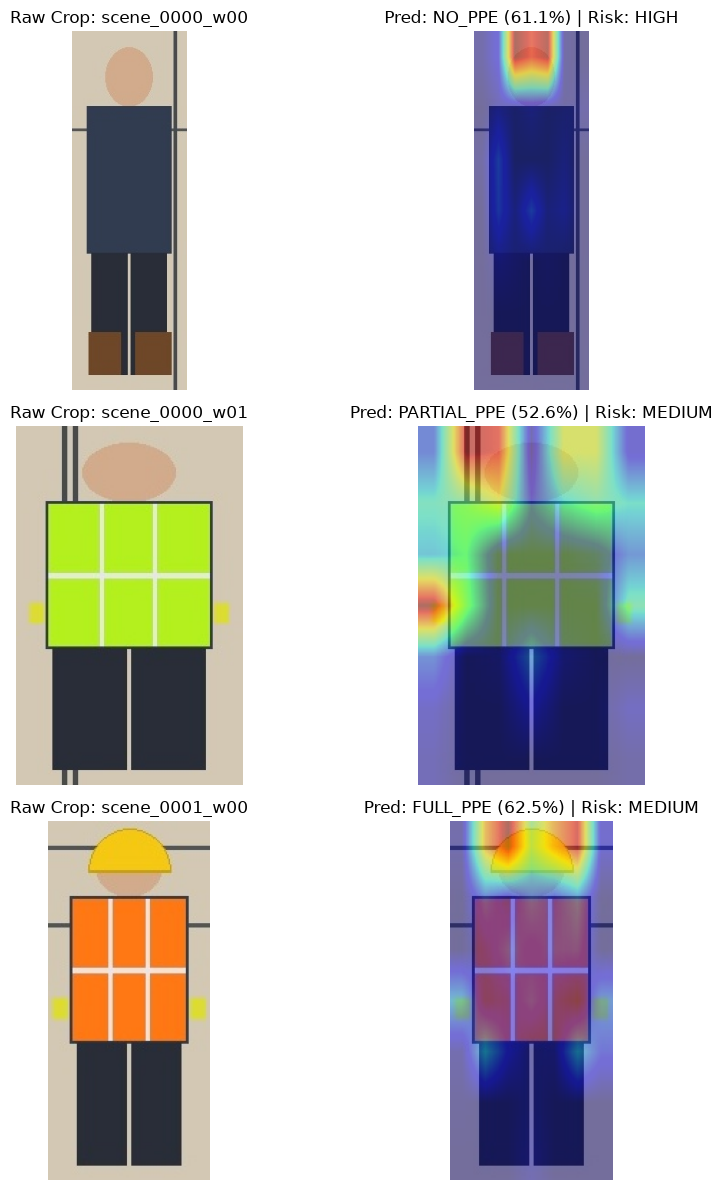

In [10]:
from app.predictor import get_predictor
from app.risk import evaluate_risk_and_recommendation

predictor = get_predictor()
crops_dir = PROJECT_ROOT / "data" / "interim" / "crops"
sample_crops = sorted(list(crops_dir.glob("*.jpg")))[:3]

fig, axes = plt.subplots(len(sample_crops), 2, figsize=(10, 4 * len(sample_crops)))
if len(sample_crops) == 1:
    axes = [axes]

for idx, crop_path in enumerate(sample_crops):
    with Image.open(crop_path) as img:
        sample_img = img.convert("RGB")
    
    res, overlay = predictor.predict_with_gradcam(sample_img)
    risk_level, rec = evaluate_risk_and_recommendation(res["prediction"], res["confidence"])
    
    # Left: Raw Image
    axes[idx][0].imshow(sample_img)
    axes[idx][0].set_title(f"Raw Crop: {crop_path.stem}")
    axes[idx][0].axis("off")
    
    # Right: Grad-CAM Overlay
    axes[idx][1].imshow(overlay)
    axes[idx][1].set_title(f"Pred: {res['prediction']} ({res['confidence']*100:.1f}%) | Risk: {risk_level}")
    axes[idx][1].axis("off")
    
    print(f"Sample {crop_path.stem}:")
    print(f"  - Prediction: {res['prediction']} (Confidence: {res['confidence']*100:.1f}%)")
    print(f"  - Risk Level: {risk_level}")
    print(f"  - Recommendation: {rec}")
    print(f"  - Latency: {res['inference_latency_ms']:.2f} ms\n")

plt.tight_layout()
plt.show()